In [4]:
import numpy as np
import pandas as pd
import scanpy as sc
import wot

from pathlib import Path

DATA_PATH = Path("/data3/projects/2025_GTRA/data/1_MND")

In [5]:
# scRNA-seq data
adata = sc.read_h5ad(DATA_PATH / "CCTSD_preproc.h5ad")
adata = adata[:,adata.var.highly_variable].copy()

In [7]:
adata.obs.columns

Index(['Time_points', 'res.0.6', 'tSNE_1', 'tSNE_2', 'cell_type', 'cell_type2',
       'timepoints', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt'],
      dtype='object')

In [8]:
time_key = "timepoints"
adata = adata[np.argsort(adata.obs[time_key].values)].copy()

In [11]:
cell_days = pd.Series(
        adata.obs[time_key].astype(float).values,
        index=adata.obs_names,
        name="day")

In [22]:
adata_wot = adata.copy()
adata_wot.obs["day"] = adata_wot.obs["timepoints"].astype(float)

In [23]:
ot_model = wot.ot.OTModel(
    adata_wot,
    day_field="day",
    lambda1 = 1.0,
    lambda2 = 50.0,
    epsilon= 0.05,
    growth_iter=3
)

In [28]:
def compute_all_transport_maps(ot_model, adata, day_field="day"):
    times = sorted(pd.unique(adata.obs[day_field]))
    tmaps = {}

    for t0, t1 in zip(times[:-1], times[1:]):
        print(f"Computing transport map: {t0} -> {t1}")
        tm = ot_model.compute_transport_map(t0, t1)
        tmaps[(t0, t1)] = tm

    return tmaps

In [38]:
import scipy.sparse as sp
import matplotlib.pyplot as plt
def unpack_transport_map(tm, source_index=None, target_index=None):
    """
    WOT transport map object를 최대한 유연하게 해석
    """
    # case 1: anndata-like
    if hasattr(tm, "X") and hasattr(tm, "obs") and hasattr(tm, "var"):
        M = tm.X
        src_idx = tm.obs.index
        tgt_idx = tm.var.index
        return M, src_idx, tgt_idx

    # case 2: dataframe
    if isinstance(tm, pd.DataFrame):
        return tm.values, tm.index, tm.columns

    # case 3: sparse / ndarray
    if sp.issparse(tm) or isinstance(tm, np.ndarray):
        return tm, source_index, target_index

    raise TypeError(f"Unknown transport map type: {type(tm)}")

def plot_transport_map(tm, title=None, max_cells=200):
    M, src_idx, tgt_idx = unpack_transport_map(tm)

    if sp.issparse(M):
        M = M.toarray()

    M = np.asarray(M)

    # 너무 크면 앞부분만 자름
    M_plot = M[:max_cells, :max_cells]

    plt.figure(figsize=(6, 5))
    plt.imshow(M_plot, aspect="auto")
    plt.xlabel("Target cells")
    plt.ylabel("Source cells")
    plt.title(title if title is not None else "Transport map")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


In [39]:
tmaps = compute_all_transport_maps(ot_model, adata_wot)

Computing transport map: 11.0 -> 13.0
Computing transport map: 13.0 -> 15.0
Computing transport map: 15.0 -> 17.0


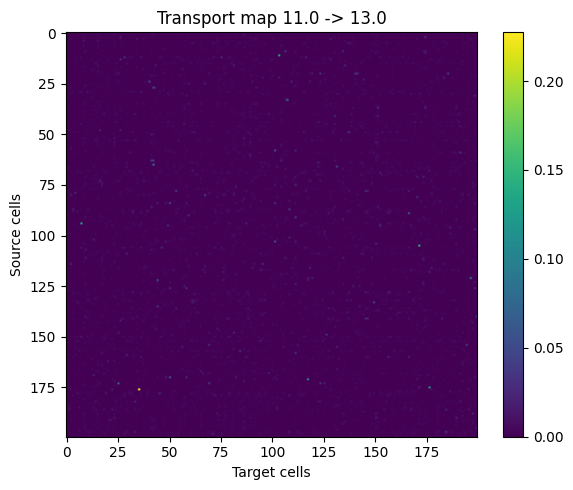

In [41]:
first_pair = list(tmaps.keys())[0]
plot_transport_map(tmaps[first_pair], title=f"Transport map {first_pair[0]} -> {first_pair[1]}")

In [45]:
tmaps[first_pair].obs

,g0,g1
TCTTATCGCCGT,1.0,0.910862
ATTGCAATAGCT,1.0,0.886006
TAAACGATCCGC,1.0,0.921098
ATAAGGGTCCGT,1.0,0.930033
AGTAAAGGACTT,1.0,0.918775
...,...,...
AACGCGCTTTTG,1.0,1.218740
AATAAGGAAGCG,1.0,0.882834
CACTACGTCTGA,1.0,0.884045
GCGGCCTCAGGN,1.0,0.941893


In [30]:
tmaps

{(np.float64(11.0),
  np.float64(13.0)): AnnData object with n_obs × n_vars = 1402 × 1129
     obs: 'g0', 'g1',
 (np.float64(13.0),
  np.float64(15.0)): AnnData object with n_obs × n_vars = 1129 × 2922
     obs: 'g0', 'g1',
 (np.float64(15.0),
  np.float64(17.0)): AnnData object with n_obs × n_vars = 2922 × 863
     obs: 'g0', 'g1'}

In [25]:
# 3. 예시 transport map
times = sorted(adata_wot.obs["day"].unique())
t0, t1 = times[0], times[1]

tm = ot_model.compute_transport_map(t0, t1)
print(type(tm))

<class 'anndata._core.anndata.AnnData'>


In [27]:
tm.obs

,g0,g1
TCTTATCGCCGT,1.0,0.910862
ATTGCAATAGCT,1.0,0.886006
TAAACGATCCGC,1.0,0.921098
ATAAGGGTCCGT,1.0,0.930033
AGTAAAGGACTT,1.0,0.918775
...,...,...
AACGCGCTTTTG,1.0,1.218740
AATAAGGAAGCG,1.0,0.882834
CACTACGTCTGA,1.0,0.884045
GCGGCCTCAGGN,1.0,0.941893
